In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, kurtosis, skew

In [9]:
age = [38, 38, 10, 8, 2]
name = ["Marge", "Homer", "Bart", "Lisa", "Maggie"]
gender = ["female", "male", "male", "female", "female"]
df1 = pd.DataFrame({"age":age, "name":name, "gender":gender})
df1

,age,name,gender
0,38,Marge,female
1,38,Homer,male
2,10,Bart,male
3,8,Lisa,female
4,2,Maggie,female


There are three types of univariate statistics that we are interested in for each variable:

1. General information: data type, count of total values, number of unique values
2. Range and middle: min, max, mean, median, mode, quartiles
3. Normality and spread: standard deviation, skewness, kurtosis

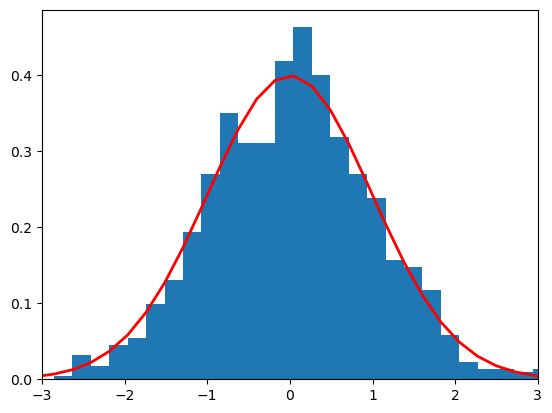

In [88]:
a = np.random.normal(0, 1, 1000)

counts, bins, ignored = plt.hist(a, 30, density=True)

plt.xlim(-3, 3)
plt.plot(bins, 1/(1 * np.sqrt(2 * np.pi)) * np.exp( - (bins - 0)**2 / (2 * 1**2) )
         , linewidth=2, color="r")
plt.show()

### Normality

"normality" in each feature's distribution. In particular, we want to understand the shape and spread of each variable. We refer tı this as the "normality" of each variable. A variable has a **normal distribution** (a.k.a. "Gaussian", or "Laplace-Gauss") when the number of cases with low values decreases as the value decreases and increases from the mean (u) while most cases have values toward the mean.

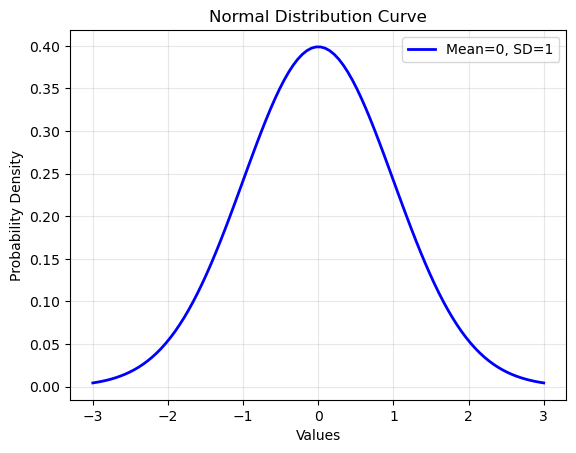

In [94]:
mean = 0
sigma = 1

x = np.linspace(mean - 3*sigma, mean + 3*sigma, 100)
y = norm.pdf(x, mean, sigma)

plt.plot(x, y, color="b", linewidth=2, label=f"Mean={mean}, SD={sigma}")
plt.title("Normal Distribution Curve")
plt.xlabel("Values")
plt.ylabel("Probability Density")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [104]:
df = pd.read_csv('data/insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [106]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [164]:
print(f"Shape: {df.shape}")
print(f"Count Age: {df.age.count()}")
print(f"Unique Smoker: {df.smoker.unique()}")
print(f"Number of Unique Region: {df.region.nunique()}")
print(f"Dtype Children: {df.children.dtype}")
print(f"Is Numeric Age: {pd.api.types.is_numeric_dtype(df.age)}")
print(f"Isnull Charges: {df.charges.isnull().sum()}")

Shape: (1338, 7)
Count Age: 1338
Unique Smoker: ['yes' 'no']
Number of Unique Region: 4
Dtype Children: int64
Is Numeric Age: True
Isnull Charges: 0


In [144]:
print(f"Min: \t\t{df.charges.min()}")
print(f"Quantile 0.25:  {df.charges.quantile(0.25)}")
print(f"Quantile 0.5:   {df.charges.quantile(0.5)}")
print(f"Quantile 0.75:  {df.charges.quantile(0.75)}")
print(f"Max: \t\t{df.charges.max()}")
print(f"Mean: \t\t{df.charges.mean()}")
print(f"Median: \t{df.charges.median()}")
print(f"Mode: \t\t{df.charges.mode()}")

Min: 		1121.8739
Quantile 0.25:  4740.28715
Quantile 0.5:   9382.033
Quantile 0.75:  16639.912515
Max: 		63770.42801
Mean: 		13270.422265141257
Median: 	9382.033
Mode: 		0    1639.5631
Name: charges, dtype: float64


In [150]:
df.charges.std() # Pandas assumes a sample std by default

12110.011236693994

In [152]:
np.std(df.charges) # Numpy uses the parameter ddof=1

12105.484975561605

### Skewness and Kurtosis

We used the term **normal** to refer to how closely a frequency count of data values matches a **bell-shape**. Identifying the degree of normality of every numeric variable is a critical outcome of the Data Understanding Phase. Although std doesn't measure how well a frequency count matches a normal distribution, there are other measures for that. Two primary measures of *ab*normality are **skewness** and **kurtosis**. Skewness measures how much the bulk of the histogram data is skewed to the right or left of the x-axis while kurtosis measures how high or low the peak of the data is. 

In [172]:
print(skew(df.charges, bias=False))
print(kurtosis(df.charges, bias=False))
print(skew(df.charges, bias=True))
print(kurtosis(df.charges, bias=True))

1.5158796580240383
1.6062986532967916
1.5141797118745743
1.595821363956751
